## Exercise : Investigating Trending Skills

In [7]:
# importing libraries 
import pandas as pd 
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

# loading dataset 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

In [ ]:
# Pivoting the data

df_DA = df[df['job_title_short']=='Data Analyst'].copy()
df_DA['Month']  = df_DA['job_posted_date'].dt.strftime('%b')
df_DA = df_DA.explode('job_skills')
df_DA
df_DA_pivoted = df_DA.pivot_table(index = "Month", columns = "job_skills", aggfunc = 'size' , fill_value=0)

In [ ]:
# sorting months in correct order

df_DA_pivoted.reset_index(inplace=True)
df_DA_pivoted['Month_no'] = pd.to_datetime(df_DA_pivoted['Month'], format='%b').dt.month
df_DA_pivoted.sort_values('Month_no',inplace=True)
df_DA_pivoted.drop(columns= ['Month_no'])
df_DA_pivoted.set_index('Month',inplace=True)

In [ ]:
# sorting columns in descending order

# df_DA_pivoted.loc['Total'] = df_DA_pivoted.sum()           # created total just to see the counts
df_ordered_columns = df_DA_pivoted.sum().sort_values(ascending = False).index.to_list()
# df_DA_pivoted.drop('Total',inplace=True)
df_DA_pivoted_ordered = df_DA_pivoted[df_ordered_columns]


Text(0.5, 0, '')

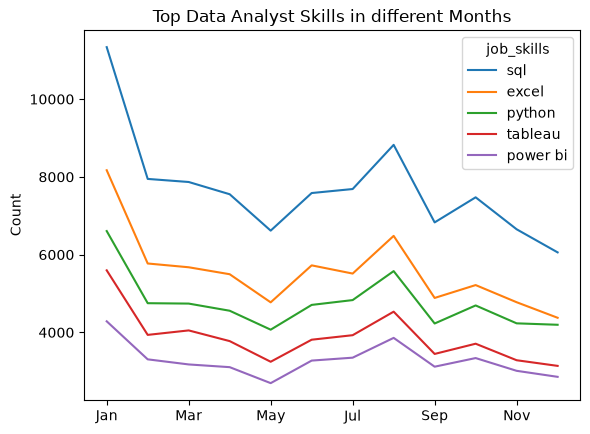

In [54]:

df_DA_pivoted_ordered.iloc[:,:5].plot(kind="line")
plt.title("Top Data Analyst Skills in different Months")
plt.ylabel("Count")
plt.xlabel("")